In [1]:
# importaçõea
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

# para visualizar os parâmetros do modelo
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

### Criando as imagens dos borrões Gaussianos

In [2]:
nGauss  = 1000
imgSize = 91

x = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)

# iniciando os tensores de imagens e labels
images = torch.zeros(nGauss,1,imgSize,imgSize)
labels = torch.zeros(nGauss,3)

for i in range(nGauss):

  # coordenadas do centro e largura aleatórias para a gaussiana
  loc = np.max(x)/2 * np.random.randn(2) # coordenadas do centro
  wid = np.random.rand()*10 + 5 # largura ou sigma da gaussiana

  # criando
  G  = np.exp( -( (X-loc[0])**2 + (Y-loc[1])**2) / wid )
  G  = G + np.random.randn(imgSize,imgSize)/10
  
  # adicionando ao tensor
  images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
  labels[i,:] = torch.Tensor( [loc[0],loc[1],wid] )

In [4]:
# visualizando algumas imagens
fig,axs = plt.subplots(3,7,figsize=(15,7))

for i,ax in enumerate(axs.flatten()):
  whichpic = np.random.randint(nGauss)
  G = np.squeeze( images[whichpic,:,:] )
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet',extent=[-4,4,-4,4],origin='upper')
  ax.set_title(f'XY=({labels[whichpic,0]:.0f},{labels[whichpic,1]:.0f}), W={labels[whichpic,2]:.0f}')
  ax.plot([-4,4],[0,0],'w--')
  ax.plot([0,0],[-4,4],'w--')
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

### Separando em treino e teste e jogando no DataLoarder

In [ ]:
# dividindo em treino e teste
train_data,test_data, train_labels,test_labels = train_test_split(images, labels, test_size=.1)

# convertendo para TensorDataset
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# criando os DataLoaders
batchsize    = 16
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [ ]:
# checando os tamanhos (imagens, canais, largura, altura)
print( train_loader.dataset.tensors[0].shape )
print( train_loader.dataset.tensors[1].shape )

torch.Size([900, 1, 91, 91])
torch.Size([900, 3])


### Criando o modelo

In [ ]:
# criando a rede neural
def makeTheNet():

  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()
      
      # usando nn.Sequential para criar a rede de forma mais compacta
      self.enc = nn.Sequential(
          
          # conv/pool block 1
          nn.Conv2d(1,6,3,padding=1),  # output size: (91+2*1-3)/1 + 1 = 91
          nn.ReLU(),                   
          nn.AvgPool2d(2,2),           # output size: 91/2 = 45
          
          # conv/pool block 2
          nn.Conv2d(6,4,3,padding=1),  # output size: (45+2*1-3)/1 + 1 = 45
          nn.ReLU(),                   
          nn.AvgPool2d(2,2),           # output size: 45/2 = 22
          
          # linear decision layer
          nn.Flatten(),                # vectorize conv2 block output
          nn.Linear(22*22*4,50),       
          nn.Linear(50,3),             
      )
      
    def forward(self,x):
      return self.enc(x)
  
  # criando a instância da rede
  net = gausnet()
  
  # loss function
  lossfun = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [8]:
# testando a reede com um batch
net,lossfun,optimizer = makeTheNet()

X,y = next(iter(train_loader))
yHat = net(X)

# checando o formato da saída
print(yHat)
print(' ')
print(yHat.shape)

# checando o valor da perda
loss = lossfun(yHat,y)
print(' ')
print('Loss:')
print(loss)

tensor([[-0.0043, -0.0581, -0.1372],
        [ 0.0043, -0.0804, -0.1266],
        [ 0.0059, -0.0496, -0.1410],
        [ 0.0021, -0.0729, -0.1361],
        [ 0.0076, -0.0808, -0.1252],
        [ 0.0178, -0.0746, -0.1236],
        [ 0.0079, -0.0753, -0.1336],
        [ 0.0021, -0.0749, -0.1327],
        [-0.0040, -0.0655, -0.1321],
        [ 0.0073, -0.0773, -0.1297],
        [ 0.0108, -0.0753, -0.1274],
        [ 0.0089, -0.0805, -0.1295],
        [-0.0005, -0.0615, -0.1308],
        [-0.0034, -0.0644, -0.1335],
        [-0.0077, -0.0501, -0.1391],
        [-0.0053, -0.0557, -0.1335]], grad_fn=<AddmmBackward0>)
 
torch.Size([16, 3])
 
Loss:
tensor(46.6460, grad_fn=<MseLossBackward0>)


### Criando a função que treina o modelo

In [ ]:
# função para treinar o modelo

def function2trainTheModel():

  # numero de épocas
  numepochs = 30
  
  # criando a rede
  net,lossfun,optimizer = makeTheNet()

  # inicializando os vetores de perda
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)


  # loop sobre as épocas
  for epochi in range(numepochs):

    # loop sobre os batches de treino
    batchLoss = []
    for X,y in train_loader:

      # forward pass e loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss deste batch
      batchLoss.append(loss.item())
    # fim do loop de batches...

    # pegando a perda média deste epoch
    trainLoss[epochi] = np.mean(batchLoss)

    # test accuracy
    X,y = next(iter(test_loader)) # extrai X,y do test dataloader
    with torch.no_grad(): # desativa autograd
      yHat = net(X)
      loss = lossfun(yHat,y)
      
    # extraindo a perda para este epoch de teste
    testLoss[epochi] = loss.item()

  # fim das épocas

  # output
  return trainLoss,testLoss,net

### Rodando o modelo

In [10]:
trainLoss,testLoss,net = function2trainTheModel()

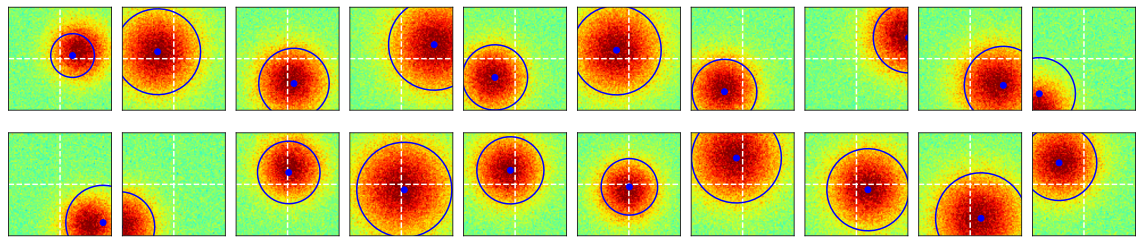

In [ ]:
# visualizando alguns resultados

X,Y = next(iter(test_loader)) # extraindo X,y do test dataloader
yHat = net(X)

fig,axs = plt.subplots(2,10,figsize=(16,4))

th = np.linspace(0,2*np.pi) # teta para desenhar o círculo da previsão do modelo

for i,ax in enumerate(axs.flatten()):

  # pegando a Gaussiana e desenhando ela, e as linhas guias
  G = torch.squeeze( X[i,0,:,:] ).detach()
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet',extent=[-4,4,-4,4],origin='lower')
  ax.plot([-4,4],[0,0],'w--')
  ax.plot([0,0],[-4,4],'w--')

  # coordenadas do centro e raio da previsão do modelo
  cx = yHat[i][0].item() # center X
  cy = yHat[i][1].item() # center Y
  rd = yHat[i][2].item() # radius

  # desenhando a previsão do modelo
  x = cx + np.cos(th)*np.sqrt(rd)
  y = cy + np.sin(th)*np.sqrt(rd)
  ax.plot(x,y,'b')
  ax.plot(cx,cy,'bo')
  
  # configurações do gráfico
  ax.set_xticks([])
  ax.set_yticks([])
  ax.set_xlim([-4,4])
  ax.set_ylim([-4,4])

plt.tight_layout()
plt.show()

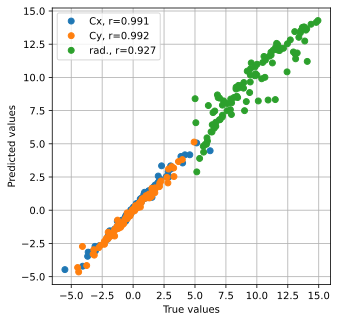

In [12]:
fig = plt.figure(figsize=(5,5))

paramNames = ['Cx','Cy','rad.']

for i in range(3):
  
  # extract parameters and compute correlation
  yy = Y[:,i].detach()
  yh = yHat[:,i].detach()
  cr = np.corrcoef(yy,yh)[0,1]

  # plot with label
  plt.plot(yy,yh,'o',label=f'{paramNames[i]}, r={cr:.3f}')


plt.legend()
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.grid()
plt.show()